In [1]:
import json
import os
import random
import sys
from collections import defaultdict

import matplotlib.pyplot as plt
import torch
from nnsight import CONFIG, LanguageModel
from torch.utils.data import DataLoader
from tqdm import tqdm
from utils import (
    error_detection,
    get_query_charac_oi,
    get_query_object_oi,
    get_reversed_sent_diff_state_counterfacts,
    get_reversed_sentence_counterfacts,
)

current_dir = os.getcwd()
sys.path.append(os.path.dirname(os.path.dirname(current_dir)))
from src import global_utils
from src.dataset import Sample, Dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(10)

CONFIG.APP.REMOTE_LOGGING = False
CONFIG.set_default_api_key(global_utils.load_env_var("NDIF_KEY"))
os.environ["HF_TOKEN"] = global_utils.load_env_var("HF_WRITE")

# Set an environment variable
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2,3,4,5"

%load_ext autoreload

/disk/u/nikhil/belief_tracking/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
all_characters = json.load(
    open(
        os.path.join(global_utils.DATA_DIR, "synthetic_entities", "characters.json"),
        "r",
    )
)
all_objects = json.load(
    open(
        os.path.join(global_utils.DATA_DIR, "synthetic_entities", "bottles.json"),
        "r",
    )
)
all_states = json.load(
    open(
        os.path.join(global_utils.DATA_DIR, "synthetic_entities", "drinks.json"),
        "r",
    )
)

print(f"#characters: {len(all_characters)}")
print(f"#objects: {len(all_objects)}")
print(f"#states: {len(all_states)}")

#characters: 103
#objects: 21
#states: 23


In [3]:
is_remote = False

if is_remote:
    model = LanguageModel("meta-llama/Llama-3.1-405B-Instruct")
else:
    model = LanguageModel(
        "meta-llama/Meta-Llama-3-70B-Instruct",
        device_map="auto",
        dtype=torch.float16,
        dispatch=True,
    )

Loading checkpoint shards: 100%|██████████| 30/30 [00:31<00:00,  1.04s/it]


In [4]:
n_errors = 100
batch_size = 1

errors = []
error_stats = defaultdict(int)
while len(errors) < n_errors:
    characters = random.sample(all_characters, 2)
    objects = random.sample(all_objects, 2)
    states = random.sample(all_states, 2)

    sample = Sample(2, characters, objects, states)
    dataset = Dataset([sample]).__getitem__(0)

    prompt = dataset["prompt"]
    target = dataset["target"]
    
    with torch.no_grad():
        with model.trace(prompt):
            pred = model.lm_head.output[0, -1].argmax(dim=-1).save()

    pred = model.tokenizer.decode(pred)
    pred = pred.lower().strip()
    target = target.lower().strip()
    if pred != target:
        error = dataset.copy()
        # print(f"Prompt: {prompt}, Target: {target}")
        # print(f"Pred: {pred}")
        error["pred"] = pred
    
        # print(f"Pred: {pred}, Target: {target}")
        print(f"Error {len(errors)} of {n_errors}")

        category = None
        if target == "unknown":
            if pred == states[0]:
                category = "unknown_but_first"
            elif pred == states[1]:
                category = "unknown_but_second"
        elif target == states[0]:
            if pred == "unknown":
                category = "first_but_unknown"
            elif pred == states[1]:
                category = "first_but_second"
        elif target == states[1]:
            if pred == "unknown":
                category = "second_but_unknown"
            elif pred == states[0]:
                category = "second_but_first"
        
        print(f"Category: {category} | Pred: {pred} | Target: {target}")
        error_stats[category] += 1
        error["category"] = category
        errors.append(error)

Error 0 of 100
Category: unknown_but_first | Pred: sprite | Target: unknown
Error 1 of 100
Category: unknown_but_first | Pred: port | Target: unknown
Error 2 of 100
Category: unknown_but_first | Pred: juice | Target: unknown
Error 3 of 100
Category: unknown_but_first | Pred: soda | Target: unknown
Error 4 of 100
Category: unknown_but_first | Pred: soda | Target: unknown
Error 5 of 100
Category: unknown_but_first | Pred: juice | Target: unknown
Error 6 of 100
Category: unknown_but_first | Pred: porter | Target: unknown
Error 7 of 100
Category: unknown_but_first | Pred: punch | Target: unknown
Error 8 of 100
Category: unknown_but_first | Pred: milk | Target: unknown
Error 9 of 100
Category: unknown_but_second | Pred: float | Target: unknown
Error 10 of 100
Category: unknown_but_first | Pred: rum | Target: unknown
Error 11 of 100
Category: unknown_but_first | Pred: gin | Target: unknown
Error 12 of 100
Category: unknown_but_first | Pred: juice | Target: unknown
Error 13 of 100
Category: u

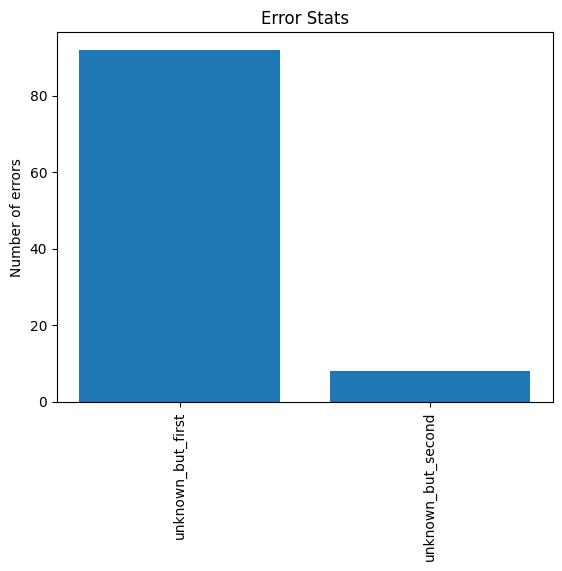

In [6]:
# Sort the error_stats by value in descending order
error_stats = dict(sorted(error_stats.items(), key=lambda item: item[1], reverse=True))

# Create a bar plot of error_stats. Rotate the x-axis labels by 90 degrees.
plt.bar(error_stats.keys(), error_stats.values())
plt.xticks(rotation=90)
plt.ylabel("Number of errors")
plt.title("Error Stats")
plt.show()


In [7]:
errors[0]

{'characters': ['Ken', 'Eve'],
 'objects': ['urn', 'tun'],
 'states': ['sprite', 'tea'],
 'story': 'Ken and Eve are working in a busy restaurant. To complete an order, Ken grabs an opaque urn and fills it with sprite. Then Eve grabs another opaque tun and fills it with tea.',
 'question': 'What does Eve believe the urn contains?',
 'target': 'unknown',
 'prompt': "Instruction: 1. Track the belief of each character as described in the story. 2. A character's belief is formed only when they perform an action themselves or can observe the action taking place. 3. A character does not have any beliefs about the container and its contents which they cannot observe. 4. To answer the question, predict only what is inside the queried container, strictly based on the belief of the character, mentioned in the question. 5. If the queried character has no belief about the container in question, then predict 'unknown'. 6. Do not predict container or character as the final output.\n\nStory: Ken and E

In [8]:
counterfactual_samples = []

while len(counterfactual_samples) < len(errors):
    idx = len(counterfactual_samples)

    trials = 0
    while True:
        sample = Sample(2, errors[idx]["characters"], errors[idx]["objects"], random.sample(all_states, 2))
        correct_sample = Dataset([sample]).__getitem__(0, set_character=errors[idx]["character_idx"], set_container=errors[idx]["object_idx"])
        prompt = correct_sample["prompt"]
        target = correct_sample["target"]
        with torch.no_grad():
            with model.trace(prompt):
                pred = model.lm_head.output[0, -1].argmax(dim=-1).save()

        pred = model.tokenizer.decode(pred)
        if pred.lower().strip() == target.lower().strip():
            counterfactual_samples.append({
                "prompt": prompt,
                "target": target,
            })
            print(f"Number of counterfactual samples: {len(counterfactual_samples)}")
            break
        
        trials += 1

        if trials > 10:
            trials = 0
            del errors[idx]
            break

Number of counterfactual samples: 1
Number of counterfactual samples: 2
Number of counterfactual samples: 3
Number of counterfactual samples: 4
Number of counterfactual samples: 5
Number of counterfactual samples: 6
Number of counterfactual samples: 7
Number of counterfactual samples: 8
Number of counterfactual samples: 9
Number of counterfactual samples: 10
Number of counterfactual samples: 11
Number of counterfactual samples: 12
Number of counterfactual samples: 13
Number of counterfactual samples: 14
Number of counterfactual samples: 15
Number of counterfactual samples: 16
Number of counterfactual samples: 17
Number of counterfactual samples: 18
Number of counterfactual samples: 19
Number of counterfactual samples: 20
Number of counterfactual samples: 21
Number of counterfactual samples: 22
Number of counterfactual samples: 23
Number of counterfactual samples: 24
Number of counterfactual samples: 25
Number of counterfactual samples: 26
Number of counterfactual samples: 27
Number of 

In [10]:
n_samples = 20
patching_dataset = []

for i in range(n_samples):
    patching_dataset.append({
        "incorrect_prompt": errors[i]["prompt"],
        "incorrect_target": errors[i]["target"],
        "incorrect_pred": errors[i]["pred"],
        "correct_prompt": counterfactual_samples[i]["prompt"],
        "correct_target": counterfactual_samples[i]["target"],
    })
    
dataloader = DataLoader(patching_dataset, batch_size=1, shuffle=False)

In [11]:
patching_dataset[0]

{'incorrect_prompt': "Instruction: 1. Track the belief of each character as described in the story. 2. A character's belief is formed only when they perform an action themselves or can observe the action taking place. 3. A character does not have any beliefs about the container and its contents which they cannot observe. 4. To answer the question, predict only what is inside the queried container, strictly based on the belief of the character, mentioned in the question. 5. If the queried character has no belief about the container in question, then predict 'unknown'. 6. Do not predict container or character as the final output.\n\nStory: Ken and Eve are working in a busy restaurant. To complete an order, Ken grabs an opaque urn and fills it with sprite. Then Eve grabs another opaque tun and fills it with tea.\nQuestion: What does Eve believe the urn contains?\nAnswer:",
 'incorrect_target': 'unknown',
 'incorrect_pred': 'sprite',
 'correct_prompt': "Instruction: 1. Track the belief of 

In [14]:
charac_indices = [131, 133, 146, 147, 158, 159]
object_indices = [150, 151, 162, 163]
state_indices = [155, 156, 167, 168]

accuracy = {}
with torch.no_grad():
    for layer_idx in tqdm(range(0, model.config.num_hidden_layers, 4)):
        correct, total = 0, 0
        for batch in dataloader:
            corrupt_act = defaultdict(dict)

            incorrect_prompt, incorrect_target, incorrect_pred = batch["incorrect_prompt"][0], batch["incorrect_target"][0], batch["incorrect_pred"][0][0]
            correct_prompt, correct_target = batch["correct_prompt"], batch["correct_target"]

            with model.trace(correct_prompt):
                for t in [-1]:
                    corrupt_act[t] = model.model.layers[layer_idx].output[:, t].save()

            with model.trace(incorrect_prompt):
                for t in [-1]:
                    model.model.layers[layer_idx].output[:, t] = corrupt_act[t]

                pred = model.lm_head.output[0, -1].argmax(dim=-1).save()

            pred = model.tokenizer.decode([pred])
            if pred.lower().strip() == incorrect_target.lower().strip():
                correct += 1
            total += 1

            del corrupt_act, pred
            torch.cuda.empty_cache()

        accuracy[layer_idx] = correct / total
        print(f"Layer: {layer_idx}, Accuracy: {correct / total}")
                    


  5%|▌         | 1/20 [00:13<04:15, 13.42s/it]

Layer: 0, Accuracy: 0.05


 10%|█         | 2/20 [00:26<03:54, 13.01s/it]

Layer: 4, Accuracy: 0.05


 15%|█▌        | 3/20 [00:39<03:41, 13.03s/it]

...

Layer: 68, Accuracy: 1.0


 95%|█████████▌| 19/20 [04:05<00:12, 12.98s/it]

Layer: 72, Accuracy: 1.0


100%|██████████| 20/20 [04:18<00:00, 12.91s/it]

Layer: 76, Accuracy: 1.0


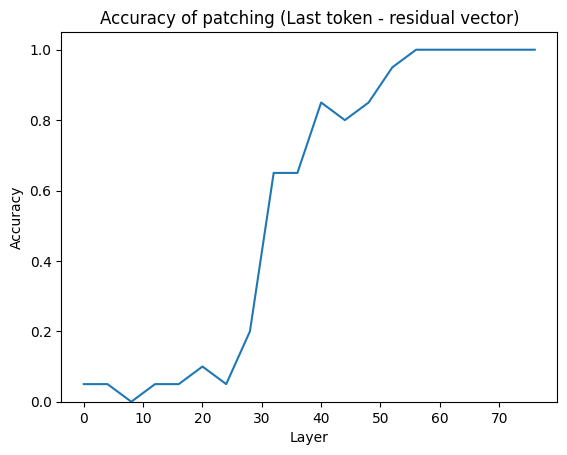

In [16]:
# plot accuracy as line plot
plt.plot(accuracy.keys(), accuracy.values())
plt.xlabel("Layer")
plt.ylabel("Accuracy")
plt.title("Accuracy of patching (Last token - residual vector)")
plt.ylim(0, 1.05)
plt.show()


In [17]:
charac_indices = [131, 133, 146, 147, 158, 159]
object_indices = [150, 151, 162, 163]
state_indices = [155, 156, 167, 168]

accuracy = {}
with torch.no_grad():
    for layer_idx in tqdm(range(0, model.config.num_hidden_layers, 4)):
        correct, total = 0, 0
        for batch in dataloader:
            corrupt_act = defaultdict(dict)

            incorrect_prompt, incorrect_target, incorrect_pred = batch["incorrect_prompt"][0], batch["incorrect_target"][0], batch["incorrect_pred"][0][0]
            correct_prompt, correct_target = batch["correct_prompt"], batch["correct_target"]

            with model.trace(correct_prompt):
                for t in [-5, -4]:
                    corrupt_act[t] = model.model.layers[layer_idx].output[:, t].save()

            with model.trace(incorrect_prompt):
                for t in [-5, -4]:
                    model.model.layers[layer_idx].output[:, t] = corrupt_act[t]

                pred = model.lm_head.output[0, -1].argmax(dim=-1).save()

            pred = model.tokenizer.decode([pred])
            if pred.lower().strip() == incorrect_target.lower().strip():
                correct += 1
            total += 1

            del corrupt_act, pred
            torch.cuda.empty_cache()

        accuracy[layer_idx] = correct / total
        print(f"Layer: {layer_idx}, Accuracy: {correct / total}")

  5%|▌         | 1/20 [00:11<03:40, 11.59s/it]

Layer: 0, Accuracy: 0.05


 10%|█         | 2/20 [00:24<03:44, 12.46s/it]

Layer: 4, Accuracy: 0.0


 15%|█▌        | 3/20 [00:38<03:41, 13.00s/it]

...

Layer: 68, Accuracy: 0.05


 95%|█████████▌| 19/20 [04:08<00:13, 13.33s/it]

Layer: 72, Accuracy: 0.05


100%|██████████| 20/20 [04:21<00:00, 13.06s/it]

Layer: 76, Accuracy: 0.05


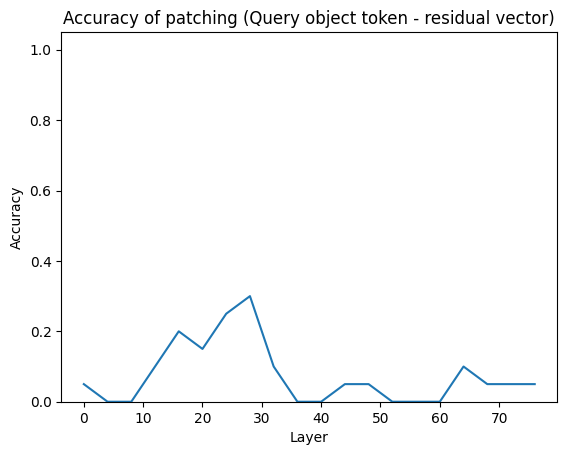

In [18]:
# plot accuracy as line plot
plt.plot(accuracy.keys(), accuracy.values())
plt.xlabel("Layer")
plt.ylabel("Accuracy")
plt.title("Accuracy of patching (Query object token - residual vector)")
plt.ylim(0, 1.05)
plt.show()


In [22]:
charac_indices = [131, 133, 146, 147, 158, 159]
object_indices = [150, 151, 162, 163]
state_indices = [155, 156, 167, 168]

accuracy = {}
with torch.no_grad():
    for layer_idx in tqdm(range(0, model.config.num_hidden_layers, 4)):
        correct, total = 0, 0
        for batch in dataloader:
            corrupt_act = defaultdict(dict)

            incorrect_prompt, incorrect_target, incorrect_pred = batch["incorrect_prompt"][0], batch["incorrect_target"][0], batch["incorrect_pred"][0][0]
            correct_prompt, correct_target = batch["correct_prompt"], batch["correct_target"]

            with model.trace(correct_prompt):
                for t in [-8, -7]:
                    corrupt_act[t] = model.model.layers[layer_idx].output[:, t].save()

            with model.trace(incorrect_prompt):
                for t in [-8, -7]:
                    model.model.layers[layer_idx].output[:, t] = corrupt_act[t]

                pred = model.lm_head.output[0, -1].argmax(dim=-1).save()

            pred = model.tokenizer.decode([pred])
            if pred.lower().strip() == incorrect_target.lower().strip():
                correct += 1
            total += 1

            del corrupt_act, pred
            torch.cuda.empty_cache()

        accuracy[layer_idx] = correct / total
        print(f"Layer: {layer_idx}, Accuracy: {correct / total}")

  5%|▌         | 1/20 [00:11<03:35, 11.36s/it]

Layer: 0, Accuracy: 0.05


 10%|█         | 2/20 [00:24<03:43, 12.44s/it]

Layer: 4, Accuracy: 0.05


 15%|█▌        | 3/20 [00:38<03:40, 12.95s/it]

...

Layer: 68, Accuracy: 0.0


 95%|█████████▌| 19/20 [04:00<00:11, 11.58s/it]

Layer: 72, Accuracy: 0.0


100%|██████████| 20/20 [04:10<00:00, 12.51s/it]

Layer: 76, Accuracy: 0.0


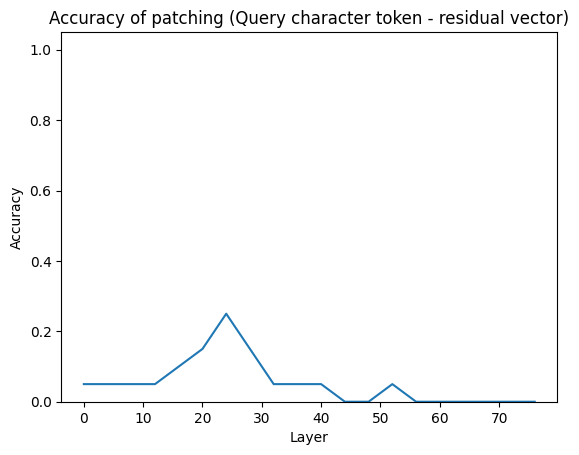

In [23]:
# plot accuracy as line plot
plt.plot(accuracy.keys(), accuracy.values())
plt.xlabel("Layer")
plt.ylabel("Accuracy")
plt.title("Accuracy of patching (Query character token - residual vector)")
plt.ylim(0, 1.05)
plt.show()

In [26]:
charac_indices = [131, 133, 146, 147, 158, 159]
object_indices = [150, 151, 162, 163]
state_indices = [155, 156, 167, 168]

accuracy = {}
with torch.no_grad():
    for layer_idx in tqdm(range(0, model.config.num_hidden_layers, 4)):
        correct, total = 0, 0
        for batch in dataloader:
            corrupt_act = defaultdict(dict)

            incorrect_prompt, incorrect_target, incorrect_pred = batch["incorrect_prompt"][0], batch["incorrect_target"][0], batch["incorrect_pred"][0][0]
            correct_prompt, correct_target = batch["correct_prompt"], batch["correct_target"]

            with model.trace(correct_prompt):
                for t in [-8, -7, -5, -4]:
                    corrupt_act[t] = model.model.layers[layer_idx].output[:, t].save()

            with model.trace(incorrect_prompt):
                for t in [-8, -7, -5, -4]:
                    model.model.layers[layer_idx].output[:, t] = corrupt_act[t]

                pred = model.lm_head.output[0, -1].argmax(dim=-1).save()

            pred = model.tokenizer.decode([pred])
            if pred.lower().strip() == incorrect_target.lower().strip():
                correct += 1
            total += 1

            del corrupt_act, pred
            torch.cuda.empty_cache()

        accuracy[layer_idx] = correct / total
        print(f"Layer: {layer_idx}, Accuracy: {correct / total}")

  5%|▌         | 1/20 [00:09<02:57,  9.35s/it]

Layer: 0, Accuracy: 0.05


 10%|█         | 2/20 [00:18<02:50,  9.46s/it]

Layer: 4, Accuracy: 0.05


 15%|█▌        | 3/20 [00:28<02:39,  9.39s/it]

...

Layer: 68, Accuracy: 0.1


 95%|█████████▌| 19/20 [03:00<00:09,  9.47s/it]

Layer: 72, Accuracy: 0.1


100%|██████████| 20/20 [03:10<00:00,  9.50s/it]

Layer: 76, Accuracy: 0.05


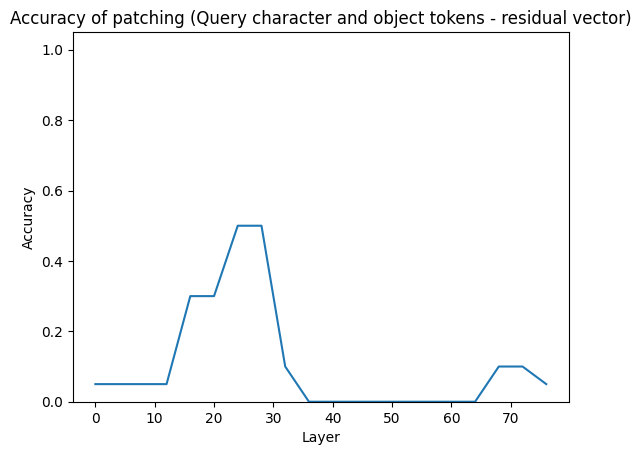

In [27]:
# plot accuracy as line plot
plt.plot(accuracy.keys(), accuracy.values())
plt.xlabel("Layer")
plt.ylabel("Accuracy")
plt.title("Accuracy of patching (Query character and object tokens - residual vector)")
plt.ylim(0, 1.05)
plt.show()

In [24]:
charac_indices = [131, 133, 146, 147, 158, 159]
object_indices = [150, 151, 162, 163]
state_indices = [155, 156, 167, 168]

accuracy = {}
with torch.no_grad():
    for layer_idx in tqdm(range(0, model.config.num_hidden_layers, 4)):
        correct, total = 0, 0
        for batch in dataloader:
            corrupt_act = defaultdict(dict)

            incorrect_prompt, incorrect_target, incorrect_pred = batch["incorrect_prompt"][0], batch["incorrect_target"][0], batch["incorrect_pred"][0][0]
            correct_prompt, correct_target = batch["correct_prompt"], batch["correct_target"]

            with model.trace(correct_prompt):
                for t in state_indices:
                    corrupt_act[t] = model.model.layers[layer_idx].output[:, t].save()

            with model.trace(incorrect_prompt):
                for t in state_indices:
                    model.model.layers[layer_idx].output[:, t] = corrupt_act[t]

                pred = model.lm_head.output[0, -1].argmax(dim=-1).save()

            pred = model.tokenizer.decode([pred])
            if pred.lower().strip() == incorrect_target.lower().strip():
                correct += 1
            total += 1

            del corrupt_act, pred
            torch.cuda.empty_cache()

        accuracy[layer_idx] = correct / total
        print(f"Layer: {layer_idx}, Accuracy: {correct / total}")

  5%|▌         | 1/20 [00:09<03:06,  9.79s/it]

Layer: 0, Accuracy: 1.0


 10%|█         | 2/20 [00:19<02:56,  9.79s/it]

Layer: 4, Accuracy: 0.95


 15%|█▌        | 3/20 [00:29<02:43,  9.63s/it]

...

Layer: 68, Accuracy: 0.1


 95%|█████████▌| 19/20 [02:59<00:09,  9.44s/it]

Layer: 72, Accuracy: 0.15


100%|██████████| 20/20 [03:09<00:00,  9.46s/it]

Layer: 76, Accuracy: 0.1


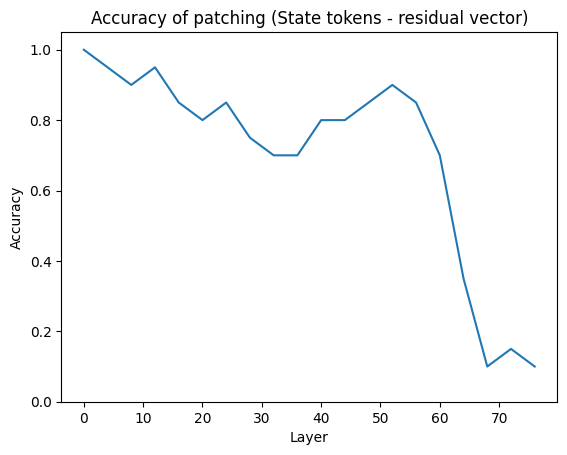

In [25]:
# plot accuracy as line plot
plt.plot(accuracy.keys(), accuracy.values())
plt.xlabel("Layer")
plt.ylabel("Accuracy")
plt.title("Accuracy of patching (State tokens - residual vector)")
plt.ylim(0, 1.05)
plt.show()

In [29]:
charac_indices = [131, 133, 146, 147, 158, 159]
object_indices = [150, 151, 162, 163]
state_indices = [155, 156, 167, 168]

accuracy = {}
with torch.no_grad():
    for layer_idx in tqdm(range(0, model.config.num_hidden_layers, 4)):
        correct, total = 0, 0
        for batch in dataloader:
            corrupt_act = defaultdict(dict)

            incorrect_prompt, incorrect_target, incorrect_pred = batch["incorrect_prompt"][0], batch["incorrect_target"][0], batch["incorrect_pred"][0][0]
            correct_prompt, correct_target = batch["correct_prompt"], batch["correct_target"]

            with model.trace(correct_prompt):
                for t in state_indices:
                    for l in range(0, layer_idx+1):
                        corrupt_act[l][t] = model.model.layers[l].self_attn.k_proj.output[:, t].save()

            with model.trace(incorrect_prompt):
                for t in state_indices:
                    for l in range(0, layer_idx+1):
                        model.model.layers[l].self_attn.k_proj.output[:, t] = corrupt_act[l][t]

                pred = model.lm_head.output[0, -1].argmax(dim=-1).save()

            pred = model.tokenizer.decode([pred])
            if pred.lower().strip() == incorrect_target.lower().strip():
                correct += 1
            total += 1

            del corrupt_act, pred
            torch.cuda.empty_cache()

        accuracy[layer_idx] = correct / total
        print(f"Layer: {layer_idx}, Accuracy: {correct / total}")

  5%|▌         | 1/20 [00:09<03:06,  9.80s/it]

Layer: 0, Accuracy: 0.0


 10%|█         | 2/20 [00:19<02:50,  9.50s/it]

Layer: 4, Accuracy: 0.0


 15%|█▌        | 3/20 [00:28<02:40,  9.43s/it]

...

Layer: 68, Accuracy: 0.75


 95%|█████████▌| 19/20 [03:13<00:10, 10.78s/it]

Layer: 72, Accuracy: 0.75


100%|██████████| 20/20 [03:24<00:00, 10.23s/it]

Layer: 76, Accuracy: 0.9


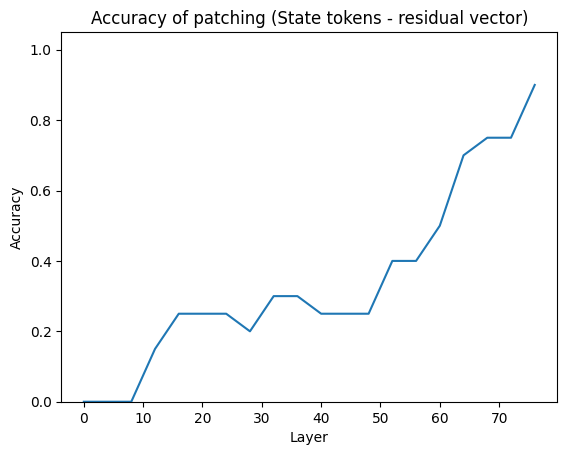

In [30]:
# plot accuracy as line plot
plt.plot(accuracy.keys(), accuracy.values())
plt.xlabel("Layer")
plt.ylabel("Accuracy")
plt.title("Accuracy of patching (State tokens - residual vector)")
plt.ylim(0, 1.05)
plt.show()

In [31]:
charac_indices = [131, 133, 146, 147, 158, 159]
object_indices = [150, 151, 162, 163]
state_indices = [155, 156, 167, 168]

accuracy = {}
with torch.no_grad():
    for layer_idx in tqdm(range(0, model.config.num_hidden_layers, 4)):
        correct, total = 0, 0
        for batch in dataloader:
            corrupt_act = defaultdict(dict)

            incorrect_prompt, incorrect_target, incorrect_pred = batch["incorrect_prompt"][0], batch["incorrect_target"][0], batch["incorrect_pred"][0][0]
            correct_prompt, correct_target = batch["correct_prompt"], batch["correct_target"]

            with model.trace(correct_prompt):
                for t in state_indices:
                    for l in range(0, layer_idx+1):
                        corrupt_act[l][t] = model.model.layers[l].self_attn.v_proj.output[:, t].save()

            with model.trace(incorrect_prompt):
                for t in state_indices:
                    for l in range(0, layer_idx+1):
                        model.model.layers[l].self_attn.v_proj.output[:, t] = corrupt_act[l][t]

                pred = model.lm_head.output[0, -1].argmax(dim=-1).save()

            pred = model.tokenizer.decode([pred])
            if pred.lower().strip() == incorrect_target.lower().strip():
                correct += 1
            total += 1

            del corrupt_act, pred
            torch.cuda.empty_cache()

        accuracy[layer_idx] = correct / total
        print(f"Layer: {layer_idx}, Accuracy: {correct / total}")

  5%|▌         | 1/20 [00:09<02:54,  9.20s/it]

Layer: 0, Accuracy: 0.05


 10%|█         | 2/20 [00:18<02:48,  9.35s/it]

Layer: 4, Accuracy: 0.2


 15%|█▌        | 3/20 [00:28<02:41,  9.47s/it]

...

Layer: 68, Accuracy: 0.75


 95%|█████████▌| 19/20 [03:10<00:10, 10.40s/it]

Layer: 72, Accuracy: 0.8


100%|██████████| 20/20 [03:21<00:00, 10.08s/it]

Layer: 76, Accuracy: 0.75


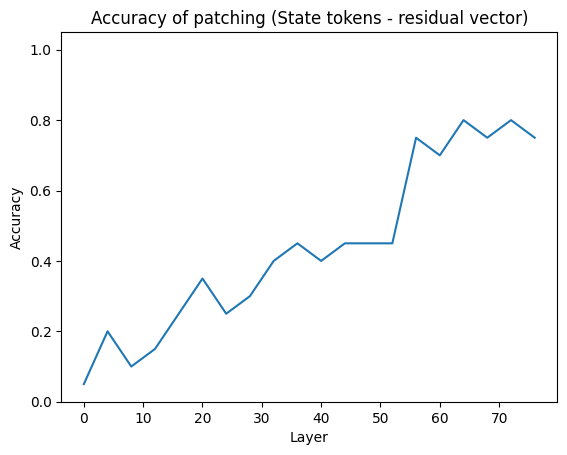

In [32]:
# plot accuracy as line plot
plt.plot(accuracy.keys(), accuracy.values())
plt.xlabel("Layer")
plt.ylabel("Accuracy")
plt.title("Accuracy of patching (State tokens - residual vector)")
plt.ylim(0, 1.05)
plt.show()

In [33]:
charac_indices = [131, 133, 146, 147, 158, 159]
object_indices = [150, 151, 162, 163]
state_indices = [155, 156, 167, 168]

accuracy = {}
with torch.no_grad():
    for layer_idx in tqdm(range(0, model.config.num_hidden_layers, 4)):
        correct, total = 0, 0
        for batch in dataloader:
            corrupt_act = defaultdict(dict)

            incorrect_prompt, incorrect_target, incorrect_pred = batch["incorrect_prompt"][0], batch["incorrect_target"][0], batch["incorrect_pred"][0][0]
            correct_prompt, correct_target = batch["correct_prompt"], batch["correct_target"]

            with model.trace(correct_prompt):
                for t in state_indices:
                    for l in range(0, layer_idx+1):
                        corrupt_act[l][t] = model.model.layers[l].self_attn.q_proj.output[:, t].save()

            with model.trace(incorrect_prompt):
                for t in state_indices:
                    for l in range(0, layer_idx+1):
                        model.model.layers[l].self_attn.q_proj.output[:, t] = corrupt_act[l][t]

                pred = model.lm_head.output[0, -1].argmax(dim=-1).save()

            pred = model.tokenizer.decode([pred])
            if pred.lower().strip() == incorrect_target.lower().strip():
                correct += 1
            total += 1

            del corrupt_act, pred
            torch.cuda.empty_cache()

        accuracy[layer_idx] = correct / total
        print(f"Layer: {layer_idx}, Accuracy: {correct / total}")

  5%|▌         | 1/20 [00:09<03:01,  9.57s/it]

Layer: 0, Accuracy: 0.05


 10%|█         | 2/20 [00:18<02:48,  9.38s/it]

Layer: 4, Accuracy: 0.1


 15%|█▌        | 3/20 [00:28<02:41,  9.51s/it]

...

Layer: 68, Accuracy: 0.2


 95%|█████████▌| 19/20 [03:10<00:10, 10.44s/it]

Layer: 72, Accuracy: 0.2


100%|██████████| 20/20 [03:21<00:00, 10.05s/it]

Layer: 76, Accuracy: 0.2


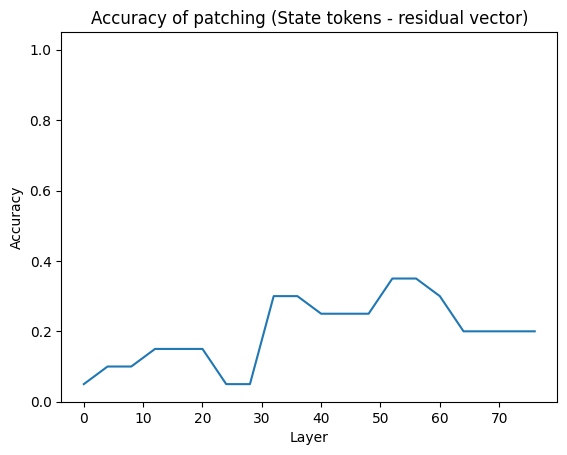

In [34]:
# plot accuracy as line plot
plt.plot(accuracy.keys(), accuracy.values())
plt.xlabel("Layer")
plt.ylabel("Accuracy")
plt.title("Accuracy of patching (State tokens - residual vector)")
plt.ylim(0, 1.05)
plt.show()